# =========================================
# NETFLIX DATA ANALYSIS PROJECT
# Internship Task 3 Submission
# Submitted By : Mayur Bavaskar
# =========================================

## TASK 3 : NETFLIX DATASET EXPLORATORY DATA ANALYSIS ( EDA )

## Problem Statement

#### The objective of this project is to perform Exploratory Data Analysis (EDA) on the Netflix dataset to identify trends, patterns, and insights 
#### related to Netflix movies and TV shows.

## 1. IMPORTING REQUIRED LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. LOADING THE DATASET

In [2]:
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 3. UNDERSTANDING THE DATASET

In [3]:
# Shape of dataset
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 8807
Number of Columns : 12


In [4]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
# Check column names
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

## STEP 4 : CHECK MISSING VALUES

In [6]:
# Missing Values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

#### Observation
##### Director column has many missing values
##### Country column has missing values
##### Cast column has missing values
##### Date Added column has missing values

## STEP 5 : DATA CLEANING AND PREPROCESSING

In [7]:
# Fill missing values

df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Not Available', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)
df['duration'].fillna(df['duration'].mode()[0], inplace=True)

# Remove rows where date_added is missing
df.dropna(subset=['date_added'], inplace=True)

In [8]:
# Check missing values again
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [9]:
# Remove unwanted spaces
df['date_added'] = df['date_added'].str.strip()

# Convert object datatype into datetime
df['date_added'] = pd.to_datetime(df['date_added'])

In [10]:
# Extract year from date_added
df['added_year'] = df['date_added'].dt.year

## STEP 6 : SUMMARY STATISTICS

In [11]:
# Statistical Summary
df.describe()

,date_added,release_year,added_year
count,8797,8797.000000,8797.000000
mean,2019-05-17 05:59:08.436966912,2014.183472,2018.871888
min,2008-01-01 00:00:00,1925.000000,2008.000000
25%,2018-04-06 00:00:00,2013.000000,2018.000000
50%,2019-07-02 00:00:00,2017.000000,2019.000000
75%,2020-08-19 00:00:00,2019.000000,2020.000000
max,2021-09-25 00:00:00,2021.000000,2021.000000
std,NaN,8.822191,1.574243


In [12]:
# Count of Movies and TV Shows
df['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

In [13]:
# Content Ratings Count
df['rating'].value_counts()

rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

## STEP 7 : DATA VISUALIZATION

### 1. Movies vs TV Show

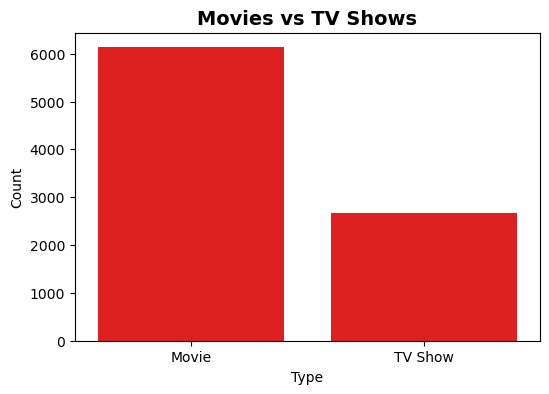

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x='type', data=df,color='red')

plt.title("Movies vs TV Shows", fontsize=14, fontweight='bold')
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

### 2. Top 10 Countries

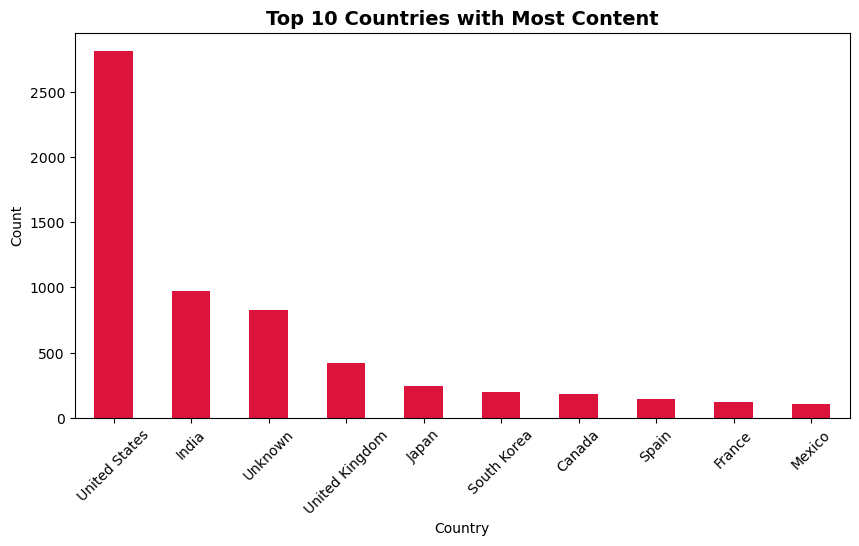

In [15]:
top_country = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_country.plot(kind='bar', color='crimson')

plt.title("Top 10 Countries with Most Content",
          fontsize=14,
          fontweight='bold')

plt.xlabel("Country")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### 3. Content Release Trend

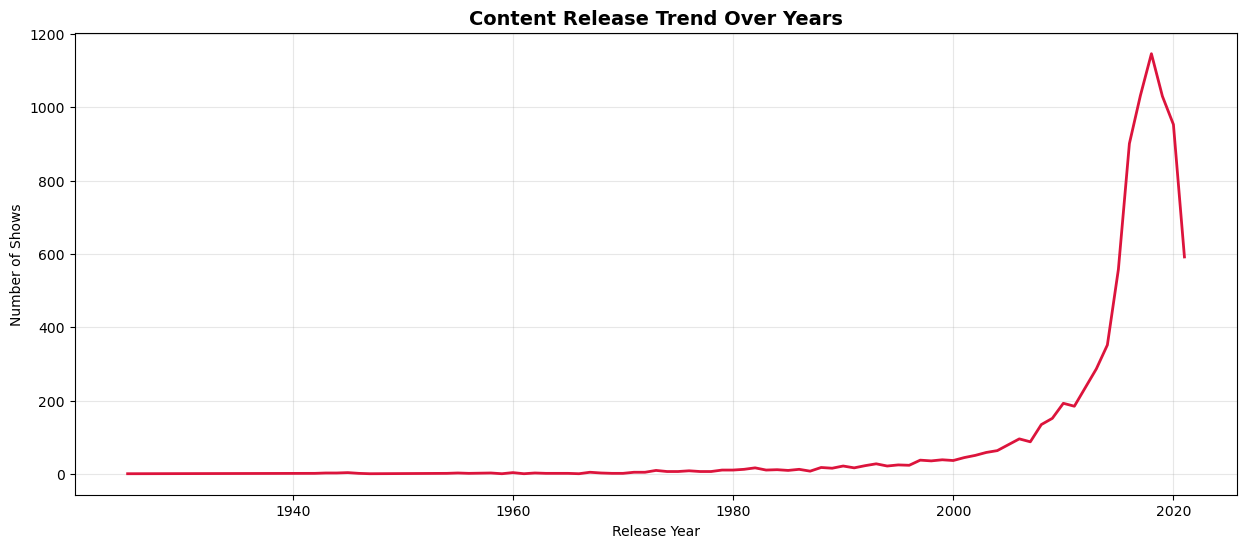

In [16]:
release_year = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(15,6))

release_year.plot(color='crimson', linewidth=2)

plt.title("Content Release Trend Over Years",
          fontsize=14,
          fontweight='bold')

plt.xlabel("Release Year")
plt.ylabel("Number of Shows")

plt.grid(alpha=0.3)

plt.show()

### 4. Rating Distribution

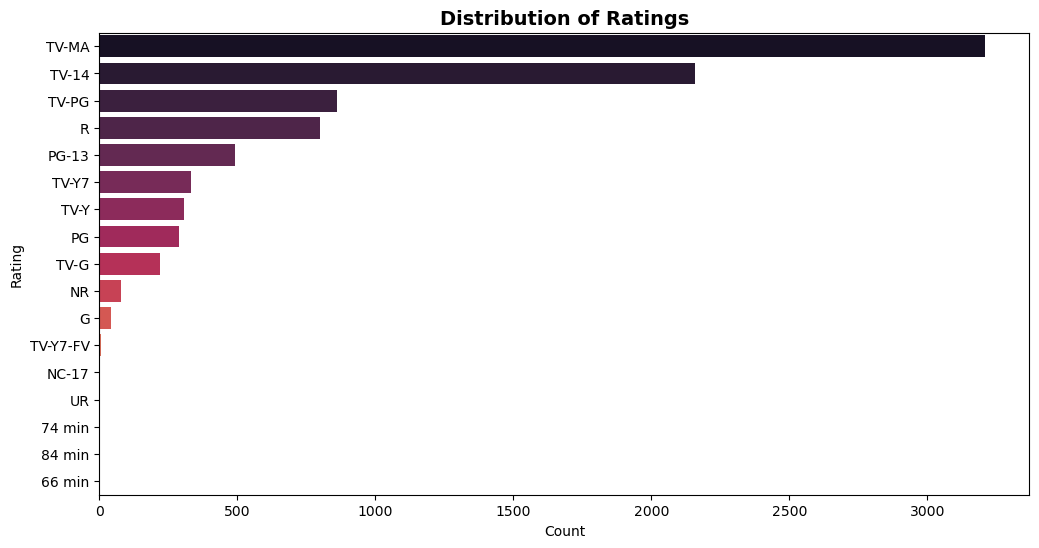

In [17]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index,
    palette='rocket'
)

plt.title("Distribution of Ratings",
          fontsize=14,
          fontweight='bold')

plt.xlabel("Count")
plt.ylabel("Rating")

plt.show()

### 5. Most Common Genres

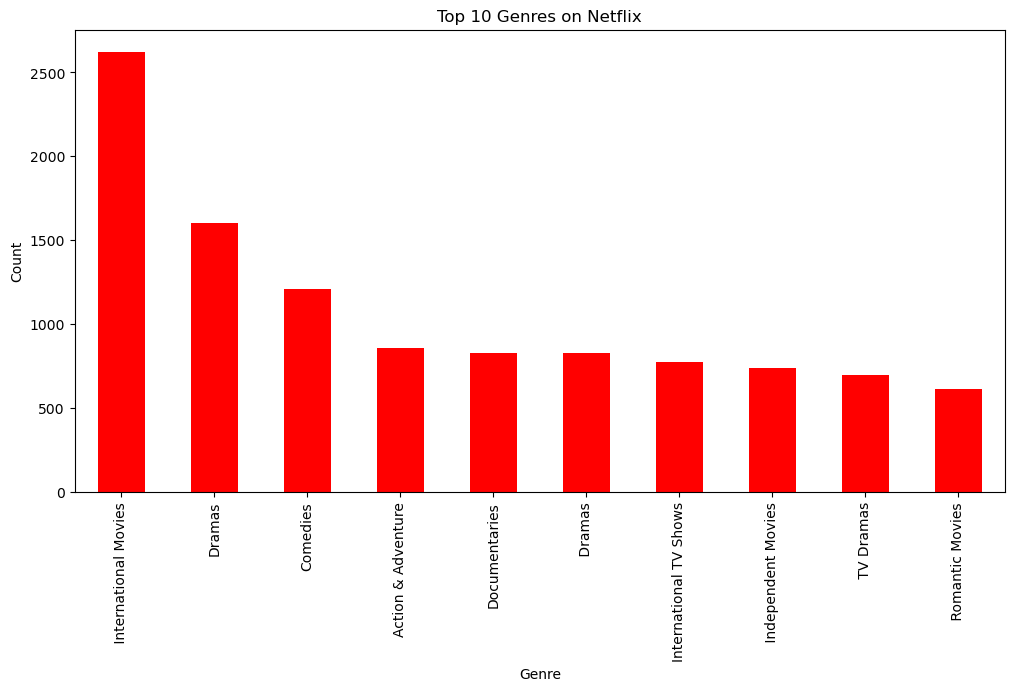

In [20]:
genre = df['listed_in'].str.split(',', expand=True).stack()

top_genre = genre.value_counts().head(10)

plt.figure(figsize=(12,6))

top_genre.plot(kind='bar',color='red')

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

              release_year  added_year
release_year      1.000000    0.111531
added_year        0.111531    1.000000


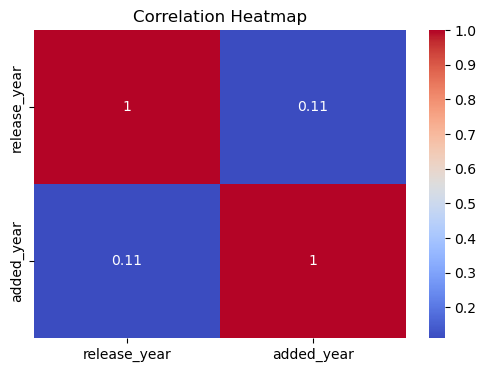

In [19]:
# Select numeric columns
numeric_data = df.select_dtypes(include=['number'])

# Create correlation matrix
correlation = numeric_data.corr()

# Print correlation
print(correlation)

# Plot heatmap
plt.figure(figsize=(6,4))

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Observation

#### The dataset contains limited numerical features, therefore correlation analysis is minimal.

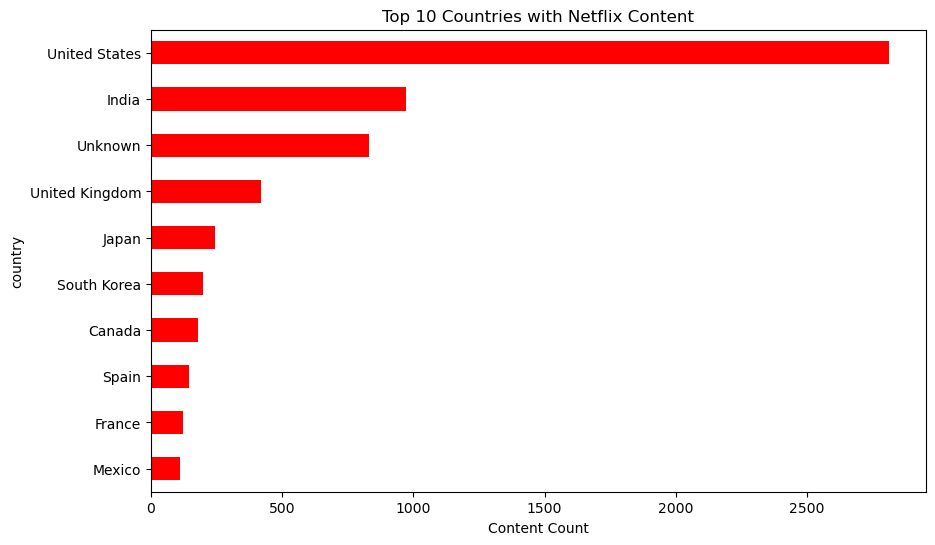

In [22]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))

top_countries.sort_values().plot(kind='barh',color='red')

plt.title("Top 10 Countries with Netflix Content")
plt.xlabel("Content Count")

plt.show()

## STEP 9 : TREND ANALYSIS

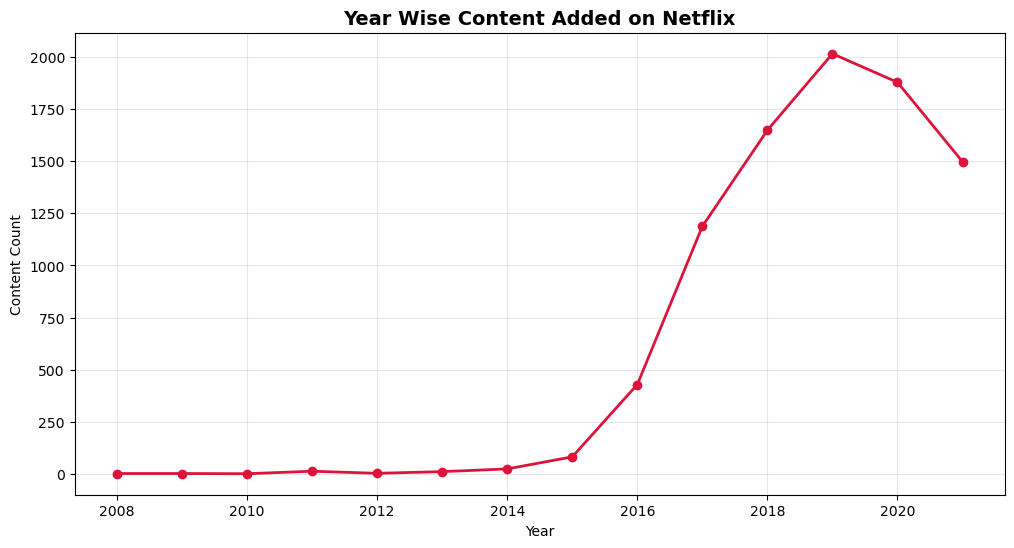

In [21]:
# Content Added Year Wise

added_year = df['added_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))

added_year.plot(marker='o',
                color='crimson',
                linewidth=2)

plt.title("Year Wise Content Added on Netflix",
          fontsize=14,
          fontweight='bold')

plt.xlabel("Year")
plt.ylabel("Content Count")

plt.grid(alpha=0.3)

plt.show()

## STEP 10 : KEY INSIGHTS

### Insights from Analysis:

##### 1.Netflix has more Movies compared to TV Shows.
##### 2.United States has the highest content on Netflix.
##### 3.Most content was added after 2015.
##### 4.3TV-MA is one of the most common ratings.
##### 5.Drama and International Movies are highly popular genres.
##### 6.Netflix content library increased rapidly after 2016.

## STEP 11 : FINAL CONCLUSION

#### Conclusion
##### This project performed Exploratory Data Analysis on the Netflix dataset. Different visualizations and statistical
##### techniques were used to identify trends and patterns.
#### The analysis showed that:
  ##### 1.Movies dominate Netflix content.
  ##### 2.Content production increased significantly in recent years.
  ##### 3.Certain genres and ratings are more common among users.
##### This EDA helps understand Netflix’s content strategy and audience preferences.

## END OF PROJECT